In [1]:
pip install mesa[rec]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.6/239.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.2/266.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.2/452.2 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.0 MB/s eta 0:00:00


In [2]:
# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

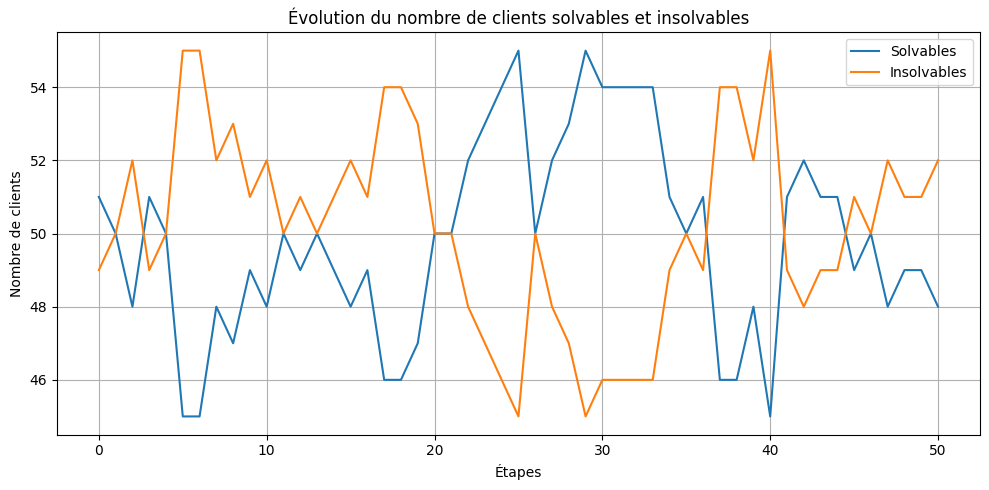

In [7]:
from mesa import Agent, Model
from mesa.datacollection import DataCollector
import random
import matplotlib.pyplot as plt

# === Agent ===
class ClientAgent(Agent):
    def __init__(self, unique_id, model):
        super().__init__(model)
        self.unique_id = unique_id
        # self.model = model
        self.solvable = random.choice([True, False])
        self.loan_amount = random.randint(5000, 20000)

    def step(self):
        # Le statut change parfois de façon aléatoire
        if random.random() < 0.05:
            self.solvable = not self.solvable


# === Modèle ===
class BankModel(Model):
    def __init__(self, N, seed=None):
        super().__init__()
        if seed is not None:
            random.seed(seed)

        self.num_agents = N
        self.client_agents = []

        for i in range(self.num_agents):
            agent = ClientAgent(i, self)
            self.client_agents.append(agent)

        self.datacollector = DataCollector(
            model_reporters={
                "Solvables": lambda m: sum(a.solvable for a in m.client_agents),
                "Insolvables": lambda m: sum(not a.solvable for a in m.client_agents),
            }
        )

        self.datacollector.collect(self)  # état initial

    def step(self):
        # activation aléatoire des agents
        random.shuffle(self.client_agents)
        for agent in self.client_agents:
            agent.step()
        self.datacollector.collect(self)


# === Simulation ===
model = BankModel(100, seed=42)

for _ in range(50):  # 50 étapes
    model.step()

# === Visualisation ===
data = model.datacollector.get_model_vars_dataframe()

plt.figure(figsize=(10, 5))
plt.plot(data["Solvables"], label="Solvables")
plt.plot(data["Insolvables"], label="Insolvables")
plt.xlabel("Étapes")
plt.ylabel("Nombre de clients")
plt.title("Évolution du nombre de clients solvables et insolvables")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
